PEM ELECTROLYZER MODEL
Temperature                  = 60.00 °C
Cathode pressure             = 30.00 bar
Anode pressure               = 30.00 bar
Maximum current density      = 20000.00 A/m²
Maximum current density      = 2.000 A/cm²
Limiting current density     = 300000.00 A/m²

Cathode roughness factor     = 233.100233
Anode roughness factor       = 685.087920

Number of cells              = 11546.73
Cell area                    = 0.2000 m²

Maximum stack power          = 94.7000 MW
Rated target power           = 94.7000 MW

Cell voltage at rated point  = 2.0504 V
Reference voltage            = 2.0400 V

H2 production at rated point = 1736.9776 kg/h
Reference H2 production      = 1765.0000 kg/h

Faraday efficiency rated     = 0.999995

Efficiency at rated point    = 18.3419 kg/MWh
SEC at rated point           = 54.5200 kWh/kg

Rated-point voltage components
--------------------------------
V_rev  = 1.293925 V
V_act  = 0.513101 V
V_ohm  = 0.243833 V
V_diff = -0.000495 V
V_cell = 2.0503

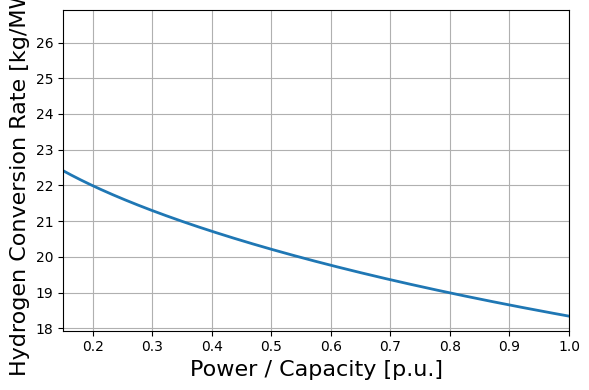

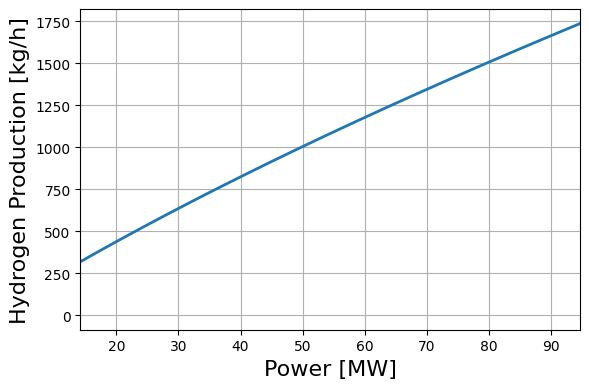

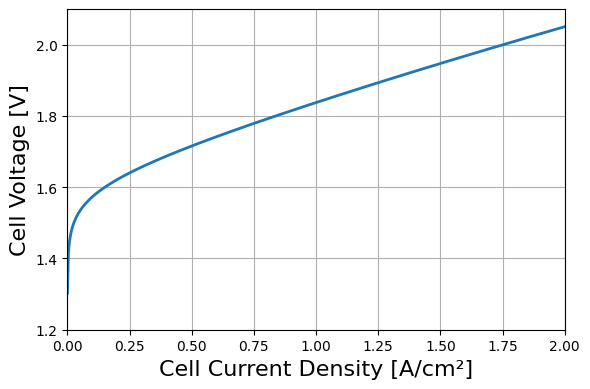

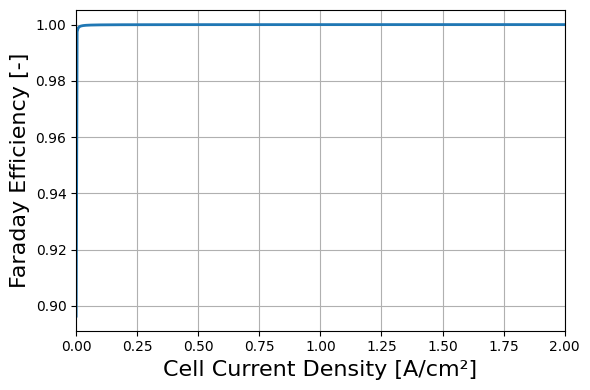

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PEM ELECTROLYZER MODEL
# ============================================================


# ============================================================
# 1. FUNDAMENTAL CONSTANTS
# ============================================================

R = 8.314                       # Universal gas constant [J/(mol K)]
F_const = 96485.0               # Faraday constant [C/mol]
M_H2 = 2.01588e-3               # Hydrogen molar mass [kg/mol]


# ============================================================
# 2. OPERATING CONDITIONS
# ============================================================

T_cell = 60.0                   # Cell temperature [°C]
T_std = 298.15                  # Standard/reference temperature [K]

p_cat = 30.0                    # Cathode operating pressure [bar]
p_an = 30.0                     # Anode operating pressure [bar]

# Rated current density:
# 2 A/cm² = 20,000 A/m²
i_max = 2.0e4                   # Maximum current density [A/m²]

i_lim = 3.0e5                   # Limiting current density [A/m²]


# ============================================================
# 3. PEM STACK REFERENCE DATA
# ============================================================

C_E = 94.7                      # Rated electrolyzer capacity [MW]

# Cell active area used for stack scaling.
# This assumption affects the calculated number of cells,
# but not the kg/MWh efficiency curve.
A_cell = 0.2                    # [m²]

V_rated_reference = 2.04        # Reference rated cell voltage [V]
H2_rated_reference = 1765.0     # Reference H2 production [kg/h]


# ============================================================
# 4. ECONOMIC / SYSTEM DATA FROM REFERENCE
# ============================================================

CAPEX_PEM = 1200.0              # [€/kW]
MR_PEM = 0.04                   # Maintenance & repair [% CAPEX/year]
stack_lifetime = 10             # [years]
BOP_lifetime = 25               # [years]
replacement_cost = 0.27         # [% CAPEX]

SEC_stack_reference = 55.7      # [kWh/kg H2]
SEC_BOP_reference = 4.0         # [kWh/kg H2]

# NOTE:
# SEC_BOP_reference is NOT included in the electrochemical
# stack efficiency calculated below.


# ============================================================
# 5. ACTIVATION PARAMETERS
# ============================================================

alpha_cat = 0.302               # Cathode charge-transfer coefficient [-]
alpha_an = 0.676                # Anode charge-transfer coefficient [-]

i0_ref_cat = 52.0               # Cathode reference exchange current density [A/m²]
i0_ref_an = 3.0e-4              # Anode reference exchange current density [A/m²]

E_act_cat = 8.96e3              # Cathode activation energy [J/mol]
E_act_an = 60.0e3               # Anode activation energy [J/mol]


# ============================================================
# 6. CATALYST PARAMETERS
# ============================================================

phi_I_cat = 0.75                # Cathode catalyst surface fraction [-]
phi_I_an = 0.75                 # Anode catalyst surface fraction [-]

m_M_cat = 0.3e-2                # Cathode catalyst loading [kg/m²]
m_M_an = 1.0e-2                 # Anode catalyst loading [kg/m²]

rho_M_cat = 21.45e3             # Cathode catalyst density [kg/m³]
rho_M_an = 22.65e3              # Anode catalyst density [kg/m³]

d_M_cat = 2.7e-9                # Cathode crystallite diameter [m]
d_M_an = 2.9e-9                 # Anode crystallite diameter [m]


# ============================================================
# 7. MEMBRANE / OHMIC PARAMETERS
# ============================================================

sigma_mem_ref = 100.9           # Reference membrane conductivity [S/m]
E_act_mem = 9.91e3              # Membrane activation energy [J/mol]
delta_mem = 1.83e-4             # Membrane thickness [m]

# Calibrated effective electrical area-specific resistance.
#
# 0.11 Ohm cm² = 1.1e-5 Ohm m²
#
# This value is used to reproduce the reported PEM polarization
# curve around 60 °C, 30 bar, and 2 A/cm².

ASR_elec_cm2 = 0.11             # [Ohm cm²]
ASR_elec = ASR_elec_cm2 * 1e-4  # [Ohm m²]


# ============================================================
# 8. FARADAY EFFICIENCY PARAMETERS
# ============================================================

# eta_F = a * i^b + c
#
# For 30 bar:
# a ≈ -0.1037

a_F = -0.1037
b_F = -1.0
c_F = 1.0


# ============================================================
# 9. REVERSIBLE VOLTAGE
# ============================================================

def p_H2O(T_C):
    """
    Water saturation pressure [bar].

    The empirical correlation is evaluated using temperature in °C.
    """
    return (
        610.0 / 1e5
    ) * np.exp(
        17.2694 * T_C / (T_C + 238.3)
    )


def E0(T_K):
    """
    Reversible voltage at standard pressure [V].
    """
    return (
        1.229
        - 0.9e-3 * (T_K - T_std)
    )


def V_rev(T_C, p_cat, p_an):
    """
    Reversible/Nernst cell voltage [V].
    """

    T_K = T_C + 273.15
    p_water = p_H2O(T_C)

    return (
        E0(T_K)
        + R * T_K / (2.0 * F_const)
        * np.log(
            (
                (p_cat - p_water)
                * np.sqrt(p_an - p_water)
            )
            / p_water
        )
    )


# ============================================================
# 10. ACTIVATION OVERPOTENTIAL
# ============================================================

def gamma_M(phi_I, m_M, rho_M, d_M):
    """
    Catalyst roughness factor [-].
    """
    return (
        phi_I
        * m_M
        * 6.0
        / (rho_M * d_M)
    )


gamma_cat = gamma_M(
    phi_I_cat,
    m_M_cat,
    rho_M_cat,
    d_M_cat
)

gamma_an = gamma_M(
    phi_I_an,
    m_M_an,
    rho_M_an,
    d_M_an
)


def i0_exchange(T_K, gamma, i0_ref, E_act):
    """
    Exchange current density [A/m²].
    """
    return (
        gamma
        * i0_ref
        * np.exp(
            -(E_act / R)
            * (
                1.0 / T_K
                - 1.0 / T_std
            )
        )
    )


def theta_bubble(T_K, i):
    """
    Fractional bubble coverage [-].
    """
    return (
        -97.25
        + 182.0 * (T_K / T_std)
        - 84.0 * (T_K / T_std)**2
    ) * (
        i / i_lim
    )**0.3


def V_act(T_C, i):
    """
    Total activation overpotential [V].
    """

    T_K = T_C + 273.15

    theta = theta_bubble(
        T_K,
        i
    )

    i0_cat = i0_exchange(
        T_K,
        gamma_cat,
        i0_ref_cat,
        E_act_cat
    )

    i0_an = i0_exchange(
        T_K,
        gamma_an,
        i0_ref_an,
        E_act_an
    )

    V_act_cat = (
        R * T_K
        / (alpha_cat * F_const)
    ) * np.arcsinh(
        i
        / (
            2.0
            * i0_cat
            * (1.0 - theta)
        )
    )

    V_act_an = (
        R * T_K
        / (alpha_an * F_const)
    ) * np.arcsinh(
        i
        / (
            2.0
            * i0_an
            * (1.0 - theta)
        )
    )

    return V_act_cat + V_act_an


# ============================================================
# 11. OHMIC OVERPOTENTIAL
# ============================================================

def sigma_mem(T_K):
    """
    Membrane ionic conductivity [S/m].
    """
    return (
        sigma_mem_ref
        * np.exp(
            -(E_act_mem / R)
            * (
                1.0 / T_K
                - 1.0 / T_std
            )
        )
    )


def ASR_mem(T_K):
    """
    Membrane area-specific resistance [Ohm m²].
    """
    return (
        delta_mem
        / sigma_mem(T_K)
    )


def ASR_eq(T_K):
    """
    Equivalent area-specific resistance [Ohm m²].
    """
    return (
        ASR_elec
        + ASR_mem(T_K)
    )


def V_ohm(T_C, i):
    """
    Ohmic overpotential [V].
    """

    T_K = T_C + 273.15

    return (
        ASR_eq(T_K)
        * i
    )


# ============================================================
# 12. DIFFUSION OVERPOTENTIAL
# ============================================================

def V_diff(T_C, i):
    """
    Diffusion overpotential [V].

    Implements:
        V_diff = RT/(4F) ln(1 - i/i_lim)

    According to the reported formulation, this contribution
    is negative for 0 < i < i_lim.
    """

    T_K = T_C + 273.15

    return (
        R * T_K
        / (4.0 * F_const)
    ) * np.log(
        1.0
        - i / i_lim
    )


# ============================================================
# 13. TOTAL CELL VOLTAGE
# ============================================================

def V_cell(T_C, p_cat, p_an, i):
    """
    PEM operating cell voltage [V].
    """
    return (
        V_rev(
            T_C,
            p_cat,
            p_an
        )
        + V_act(
            T_C,
            i
        )
        + V_ohm(
            T_C,
            i
        )
        + V_diff(
            T_C,
            i
        )
    )


# ============================================================
# 14. FARADAY EFFICIENCY
# ============================================================

def eta_F(i):
    """
    PEM Faraday efficiency [-].

    Current density must be provided in A/m².
    """
    return (
        a_F * i**b_F
        + c_F
    )


# ============================================================
# 15. STACK SCALING
# ============================================================

def n_cell(
    i_max,
    A_cell,
    C_E,
    T_C,
    p_cat,
    p_an
):
    """
    Number of cells required for the stack to reach
    rated capacity C_E at i_max.
    """

    I_max_cell = (
        i_max
        * A_cell
    )

    V_max_cell = V_cell(
        T_C,
        p_cat,
        p_an,
        i_max
    )

    P_max_cell = (
        I_max_cell
        * V_max_cell
    )

    return (
        C_E * 1e6
        / P_max_cell
    )


# ============================================================
# 16. HYDROGEN PRODUCTION
# ============================================================

def H2_production(i, A_cell, n_c):
    """
    Hydrogen production rate [kg/h].
    """

    n_H2_mol_s = (
        eta_F(i)
        * n_c
        * i
        * A_cell
        / (
            2.0
            * F_const
        )
    )

    return (
        n_H2_mol_s
        * M_H2
        * 3600.0
    )


# ============================================================
# 17. STACK POWER
# ============================================================

def stack_power(
    T_C,
    p_cat,
    p_an,
    i,
    A_cell,
    n_c
):
    """
    PEM stack electrical power [MW].
    """

    return (
        V_cell(
            T_C,
            p_cat,
            p_an,
            i
        )
        * i
        * A_cell
        * n_c
        / 1e6
    )


# ============================================================
# 18. STACK EFFICIENCY
# ============================================================

def eta_kg_per_MWh(
    T_C,
    p_cat,
    p_an,
    i,
    A_cell,
    n_c
):
    """
    PEM stack hydrogen-conversion rate [kg/MWh].
    """

    P_MW = stack_power(
        T_C,
        p_cat,
        p_an,
        i,
        A_cell,
        n_c
    )

    H2_kg_h = H2_production(
        i,
        A_cell,
        n_c
    )

    return (
        H2_kg_h
        / P_MW
    )


# ============================================================
# 19. CURRENT-DENSITY RANGE
# ============================================================

# Avoid i = 0 because:
#
# eta_F = 1 - 0.1037/i
#
# contains i^(-1).

i = np.linspace(
    1.0,
    i_max,
    500
)


# ============================================================
# 20. DETERMINE NUMBER OF CELLS
# ============================================================

n_c = n_cell(
    i_max,
    A_cell,
    C_E,
    T_cell,
    p_cat,
    p_an
)


# ============================================================
# 21. CALCULATE VOLTAGE COMPONENTS
# ============================================================

V_rev_values = np.full_like(
    i,
    V_rev(
        T_cell,
        p_cat,
        p_an
    )
)

V_act_values = V_act(
    T_cell,
    i
)

V_ohm_values = V_ohm(
    T_cell,
    i
)

V_diff_values = V_diff(
    T_cell,
    i
)

V_cell_values = V_cell(
    T_cell,
    p_cat,
    p_an,
    i
)


# ============================================================
# 22. CALCULATE STACK POWER
# ============================================================

P_elec = stack_power(
    T_cell,
    p_cat,
    p_an,
    i,
    A_cell,
    n_c
)


# ============================================================
# 23. CALCULATE HYDROGEN PRODUCTION
# ============================================================

H2_prod_kg_h = H2_production(
    i,
    A_cell,
    n_c
)


# ============================================================
# 24. CALCULATE FARADAY EFFICIENCY
# ============================================================

eta_F_values = eta_F(i)


# ============================================================
# 25. CALCULATE HYDROGEN-CONVERSION RATE
# ============================================================

efficiency_kg_per_MWh = eta_kg_per_MWh(
    T_cell,
    p_cat,
    p_an,
    i,
    A_cell,
    n_c
)


# ============================================================
# 26. NORMALIZED POWER
# ============================================================

P_base = np.max(P_elec)

P_elec_pu = (
    P_elec
    / P_base
)


# ============================================================
# 27. BASIC MODEL INFORMATION
# ============================================================

print("======================================================")
print("PEM ELECTROLYZER MODEL")
print("======================================================")

print(f"Temperature                  = {T_cell:.2f} °C")
print(f"Cathode pressure             = {p_cat:.2f} bar")
print(f"Anode pressure               = {p_an:.2f} bar")

print(
    f"Maximum current density      = "
    f"{i_max:.2f} A/m²"
)

print(
    f"Maximum current density      = "
    f"{i_max/1e4:.3f} A/cm²"
)

print(
    f"Limiting current density     = "
    f"{i_lim:.2f} A/m²"
)

print()

print(
    f"Cathode roughness factor     = "
    f"{gamma_cat:.6f}"
)

print(
    f"Anode roughness factor       = "
    f"{gamma_an:.6f}"
)

print()

print(
    f"Number of cells              = "
    f"{n_c:.2f}"
)

print(
    f"Cell area                    = "
    f"{A_cell:.4f} m²"
)

print()

print(
    f"Maximum stack power          = "
    f"{P_elec[-1]:.4f} MW"
)

print(
    f"Rated target power           = "
    f"{C_E:.4f} MW"
)

print()

print(
    f"Cell voltage at rated point  = "
    f"{V_cell_values[-1]:.4f} V"
)

print(
    f"Reference voltage            = "
    f"{V_rated_reference:.4f} V"
)

print()

print(
    f"H2 production at rated point = "
    f"{H2_prod_kg_h[-1]:.4f} kg/h"
)

print(
    f"Reference H2 production      = "
    f"{H2_rated_reference:.4f} kg/h"
)

print()

print(
    f"Faraday efficiency rated     = "
    f"{eta_F_values[-1]:.6f}"
)

print()

print(
    f"Efficiency at rated point    = "
    f"{efficiency_kg_per_MWh[-1]:.4f} kg/MWh"
)

print(
    f"SEC at rated point           = "
    f"{1000.0 / efficiency_kg_per_MWh[-1]:.4f} kWh/kg"
)

print("======================================================")


# ============================================================
# 28. RATED-POINT VOLTAGE BREAKDOWN
# ============================================================

print()
print("Rated-point voltage components")
print("--------------------------------")

print(
    f"V_rev  = "
    f"{V_rev(T_cell, p_cat, p_an):.6f} V"
)

print(
    f"V_act  = "
    f"{V_act(T_cell, i_max):.6f} V"
)

print(
    f"V_ohm  = "
    f"{V_ohm(T_cell, i_max):.6f} V"
)

print(
    f"V_diff = "
    f"{V_diff(T_cell, i_max):.6f} V"
)

print(
    f"V_cell = "
    f"{V_cell(T_cell, p_cat, p_an, i_max):.6f} V"
)


# ============================================================
# 29. PLOT:
# HYDROGEN-CONVERSION RATE vs NORMALIZED POWER
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    P_elec_pu,
    efficiency_kg_per_MWh,
    linewidth=2
)

plt.xlabel(
    "Power / Capacity [p.u.]",
    fontsize=16
)

plt.ylabel(
    "Hydrogen Conversion Rate [kg/MWh]",
    fontsize=16
)

plt.xlim(
    0.15,
    1.0
)

plt.grid()
plt.tight_layout()

plt.savefig(
    "PEM_Efficiency_curve.pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


# ============================================================
# 30. PLOT:
# HYDROGEN PRODUCTION vs POWER
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    P_elec,
    H2_prod_kg_h,
    linewidth=2
)

plt.xlabel(
    "Power [MW]",
    fontsize=16
)

plt.ylabel(
    "Hydrogen Production [kg/h]",
    fontsize=16
)

plt.xlim(
    0.15 * P_base,
    P_base
)

plt.grid()
plt.tight_layout()

plt.savefig(
    "PEM_Hydrogen_production.pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


# ============================================================
# 31. PLOT:
# POLARIZATION CURVE
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    i / 1e4,
    V_cell_values,
    linewidth=2
)

plt.xlabel(
    "Cell Current Density [A/cm²]",
    fontsize=16
)

plt.ylabel(
    "Cell Voltage [V]",
    fontsize=16
)

plt.xlim(
    0.0,
    2.0
)

plt.ylim(
    1.2,
    2.1
)

plt.grid()
plt.tight_layout()

plt.savefig(
    "PEM_Polarization_curve.pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()


# ============================================================
# 32. PLOT:
# FARADAY EFFICIENCY vs CURRENT DENSITY
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    i / 1e4,
    eta_F_values,
    linewidth=2
)

plt.xlabel(
    "Cell Current Density [A/cm²]",
    fontsize=16
)

plt.ylabel(
    "Faraday Efficiency [-]",
    fontsize=16
)

plt.xlim(
    0.0,
    2.0
)

plt.grid()
plt.tight_layout()

plt.savefig(
    "PEM_Faraday_efficiency.pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()